<a href="https://colab.research.google.com/github/StillGrowing-25/Applied-Machine-Learning/blob/main/Handwritten%20Digit%20Recognition/Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

Loading dataset and libraries

In [13]:
train_data = pd.read_csv('/content/Train.csv', on_bad_lines='skip', engine='python')
print("Shape of train_data:", train_data.shape)

X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

print("Shape of X after separating features:", X.shape)

Shape of train_data: (19478, 785)
Shape of X after separating features: (19478, 784)


Preprcessing

In [14]:
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
X = X.values / 255.0
X = X.reshape(-1, 28, 28, 1)
print("Shape of X after reshaping:", X.shape)

Shape of X after reshaping: (19478, 28, 28, 1)


One hot encoding

In [15]:
y = to_categorical(y, num_classes=10)
print("Shape of y after one-hot encoding:", y.shape)

Shape of y after one-hot encoding: (19478, 10)


Split data

In [16]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)

X_train shape: (15582, 28, 28, 1)


Build neural network model

In [17]:
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [18]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8735 - loss: 0.4358 - val_accuracy: 0.9179 - val_loss: 0.2684
Epoch 2/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9450 - loss: 0.1827 - val_accuracy: 0.9466 - val_loss: 0.1815
Epoch 3/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9632 - loss: 0.1208 - val_accuracy: 0.9502 - val_loss: 0.1649
Epoch 4/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9725 - loss: 0.0896 - val_accuracy: 0.9487 - val_loss: 0.1702
Epoch 5/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9808 - loss: 0.0638 - val_accuracy: 0.9538 - val_loss: 0.1574
Epoch 6/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9852 - loss: 0.0495 - val_accuracy: 0.9543 - val_loss: 0.1581
Epoch 7/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.9541 - val_loss: 0.1590
Epoch 8/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9919 - loss: 0.0260 - val_accuracy: 0

Evaluate the model

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9602 - loss: 0.1792
Validation Accuracy: 96.02%


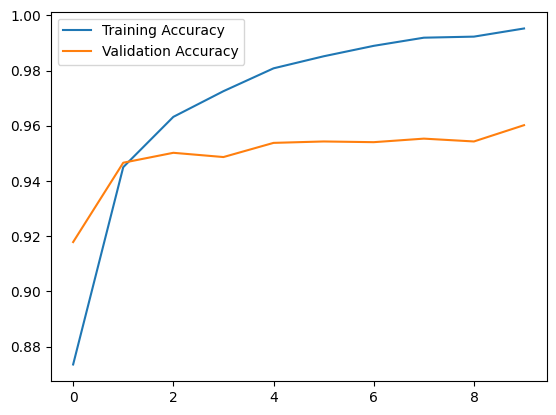

In [19]:
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

Prediction

718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


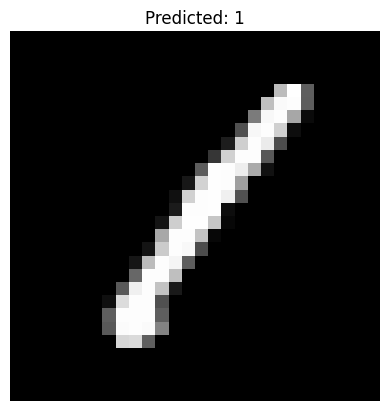

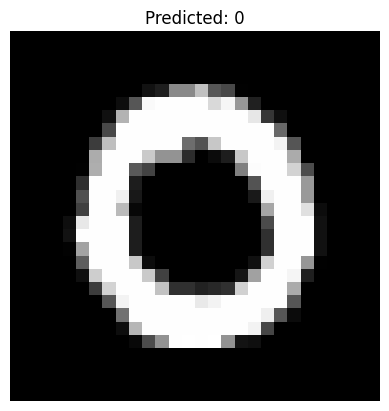

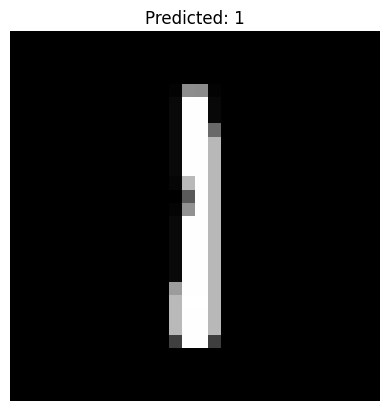

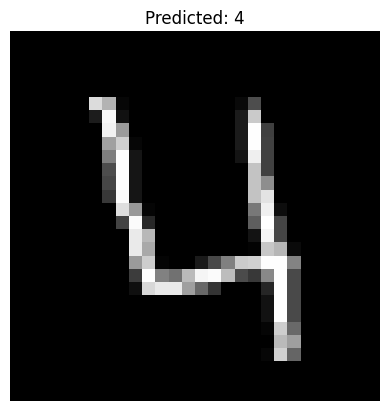

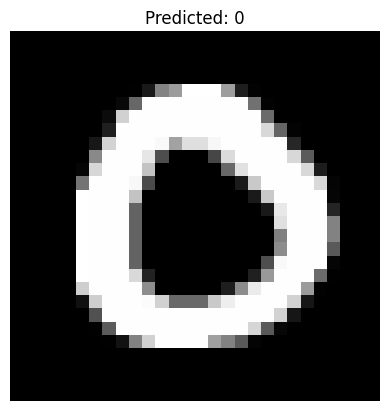

In [22]:
test_data = pd.read_csv('/content/test.csv')
X_test = test_data.iloc[:, 1:].values / 255.0  # Exclude the label column
X_test = X_test.reshape(-1, 28, 28, 1)
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()